# Nearest Neighbors Classification: Scaling the data


Adapted by <alberto.suarez@uam.es>

from
Scikit-learn: Machine Learning in Python, Pedregosa et al., JMLR 12, pp. 2825-2830, 2011.

https://scikit-learn.org/stable/auto_examples/neighbors/plot_classification.html#sphx-glr-auto-examples-neighbors-plot-classification-py

Version: Final

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

# Import necessary libraries

import numpy as np
import matplotlib.pyplot as plt
from sklearn import neighbors, datasets 
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

# Plotting utilities
import utilities.plot_utilities as pltu

In [2]:
# Auxiliary functions

def plot_knn_2D_decision_regions_aux(X, y, 
                                     classifier,
                                     feature_names,
                                     ax=None,
                                     fontsize=14):
    """ Plot decision regions for this specific example 
        knn with a 2D feature space.
    """
    
    pltu.plot_2D_decision_regions(
        X, 
        y,
        decision_function=classifier.predict, 
        cmap=plt.cm.rainbow,
        ax=ax,        
        fontsize=fontsize,
    )
      
    ax.set_title('kNN classification (k = {})'.format(classifier.n_neighbors), 
                 fontsize=fontsize)
    
    ax.set_xlabel(feature_names[0], 
                  fontsize=fontsize)
    ax.set_ylabel(feature_names[1],
                  fontsize=fontsize)

def plot_knn_2D_decision_regions(X_train, y_train, 
                                 X_test, y_test,
                                 classifier,
                                 feature_names,
                                 fontsize=14):

    """ Plot the decision regions """ 

    fig, axs = plt.subplots(1, 2, figsize=(12, 6))

    plot_knn_2D_decision_regions_aux(X_train, y_train, 
                                     classifier,
                                     feature_names,
                                     ax=axs[0],
                                     fontsize=fontsize)

    plot_knn_2D_decision_regions_aux(X_test, y_test, 
                                     classifier,
                                     feature_names,
                                     ax=axs[1],
                                     fontsize=fontsize)

    axs[1].set_title('Test data', fontsize=fontsize)

    # Compute predictions and error on the test set 

    y_test_pred = classifier.predict(X_test)

    err_test = 1.0 - accuracy_score(y_test, y_test_pred)
    print()
    print('Test error = {:6.2f} %'.format(100.0*err_test)) 
    print()
    print('Confusion matrix:')
    print(confusion_matrix(y_test, y_test_pred))


Test error =  24.44 %

Confusion matrix:
[[14  0  0]
 [ 0 12  6]
 [ 0  5  8]]


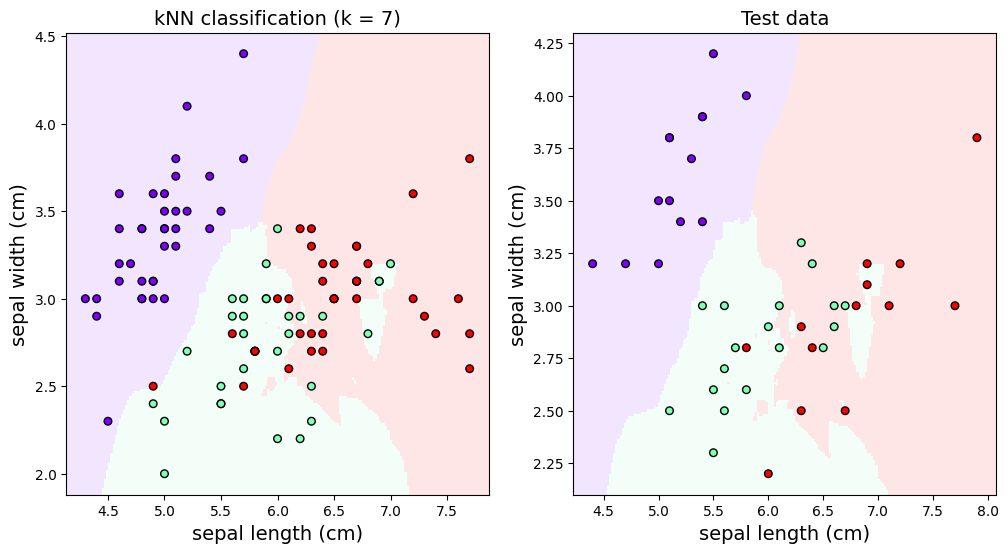

In [3]:
# Import a dataset.
dataset = datasets.load_iris()

X = dataset.data
y = dataset.target

# Consider only two features. 
indices_features = [0, 1]
X = X[:, indices_features]
feature_names = [dataset.feature_names[index] for index in indices_features]

# Number of neighbors for kNN (k nearest neighbors).
n_neighbors = 7

# Create an instance of a Neighbours Classifier
classifier = neighbors.KNeighborsClassifier(n_neighbors, 
                                            weights='uniform')

# Partition the data into training and test sets
"""
One should always shuffle (the samples may be ordered according to their class label) 
Stratification = Similar class proportions in training / test data
"""
random_state = 1 # For reproducibility 
X_train, X_test, y_train,  y_test = train_test_split(X, y, 
                                                     test_size=0.3, 
                                                     random_state=random_state, 
                                                     shuffle=True) 
# Train the classifier using the data
classifier.fit(X_train, y_train)
    
plot_knn_2D_decision_regions(X_train, y_train, 
                             X_test, y_test,
                             classifier,
                             feature_names)

# Change the scale of one attribute

In [4]:
# Select a feature to scale.
index_scaled_feature = indices_features[0] 

# Create a reference to the selected feature.

scaled_feature = dataset.data[:, index_scaled_feature] 

old_name = dataset.feature_names[index_scaled_feature]
print('Old name = "{}"   Mean = {:.4f} cm'.format(old_name, 
                                              np.mean(scaled_feature)))
# Scale the selected feature
factor_cm_to_mm = 10.0

# scaled_feature = scaled_feature*factor_cm_to_mm #  Creates a copy.
scaled_feature *= factor_cm_to_mm # In place (does not create a copy).

# Change the name of the selected feature to reflect the new units.

new_name = old_name[:-4] + '(mm)'
dataset.feature_names[index_scaled_feature] = new_name
      
print('New name = "{}"   Mean = {:.4f} mm'.format(dataset.feature_names[index_scaled_feature], 
                                                  np.mean(dataset.data[:, index_scaled_feature])))

Old name = "sepal length (cm)"   Mean = 5.8433 cm
New name = "sepal length (mm)"   Mean = 58.4333 mm



Test error =  28.89 %

Confusion matrix:
[[13  1  0]
 [ 1 10  7]
 [ 0  4  9]]


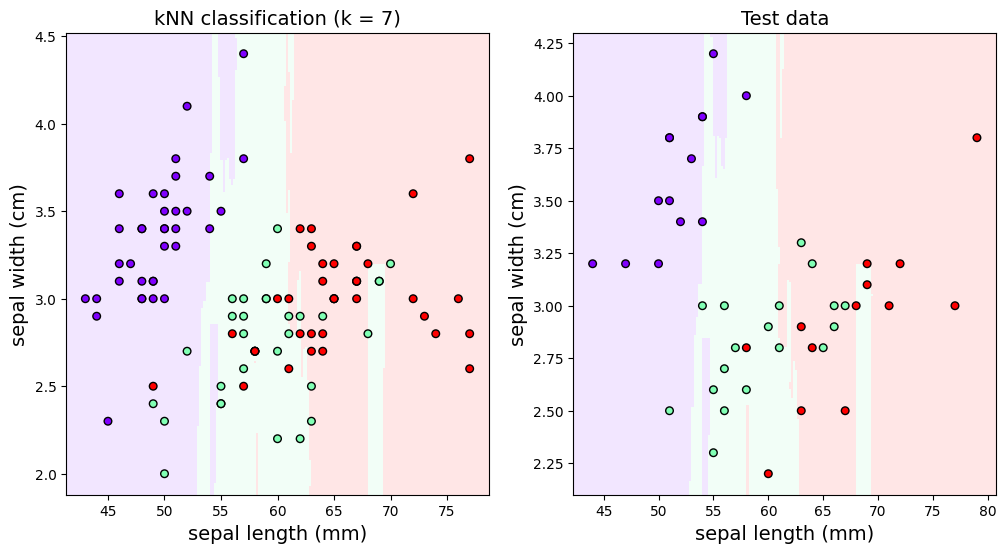

In [5]:
# Data from the modified dataset
X = dataset.data
y = dataset.target

# Consider only two features. 
indices_features = [0, 1]
X = X[:, indices_features]
feature_names = [dataset.feature_names[index] for index in indices_features]

# Partition the data into training and test sets

X_train, X_test, y_train,  y_test = train_test_split(X, y, 
                                                     test_size=0.3, 
                                                     random_state=random_state, 
                                                     shuffle=True) 
# Train the classifier using the data
classifier.fit(X_train, y_train)
   
plot_knn_2D_decision_regions(X_train, y_train, 
                             X_test, y_test,
                             classifier,
                             feature_names)

# Classification with centering and scaling.
## (Generally better generalization performance)

Training set attributes:
Mean  =  [-2.96059473e-17 -1.81442163e-15]
Stdev =  [1. 1.]

Test set attributes:
Mean  =  [0.17185101 0.15382693]
Stdev =  [0.92720042 1.12682132]

Test error =  20.00 %

Confusion matrix:
[[14  0  0]
 [ 0 12  6]
 [ 0  3 10]]


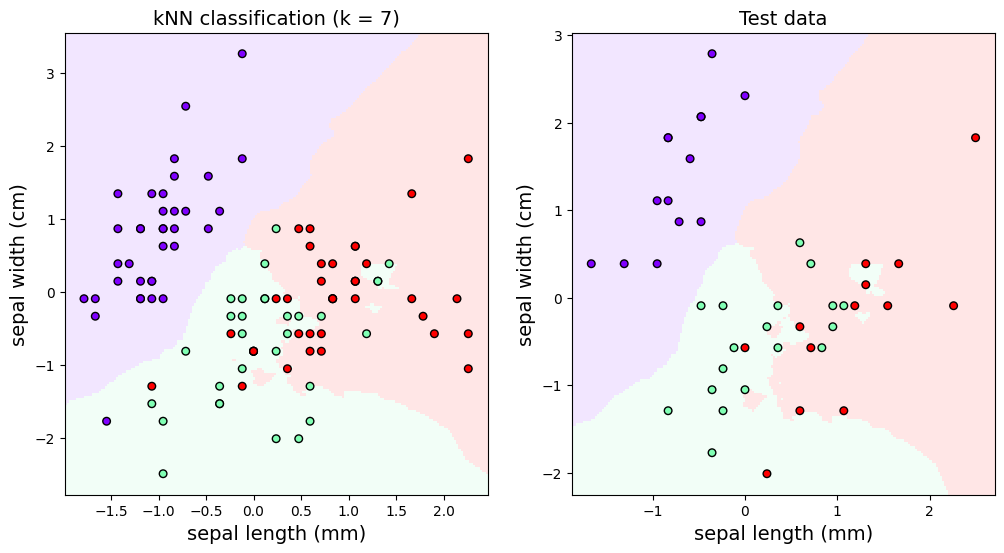

In [6]:
# Center and scale the data
from sklearn import preprocessing

# Initialize an instance of the StandardScaler class 
scaler_train = preprocessing.StandardScaler()

# Find the parameters for centering and scaling from the training data
scaler_train.fit(X_train)

# IMPORTANT: Center and scale both training and testing data 
# with parameters for centering and scaling from the training data
 
X_train_scaled = scaler_train.transform(X_train)
X_test_scaled = scaler_train.transform(X_test)

# After centering and scaling attributes in the training set
# have zero mean and unit standard deviation
print('Training set attributes:')
print('Mean  = ',  np.mean(X_train_scaled, axis=0))
print('Stdev = ',  np.std(X_train_scaled, axis=0))

print()

# After centering and scaling attributes in the test set
# have approximately zero mean and unit standard deviation
print('Test set attributes:')
print('Mean  = ',  np.mean(X_test_scaled, axis=0))
print('Stdev = ',  np.std(X_test_scaled, axis=0))


# Train the classifier using the scaled data
classifier.fit(X_train_scaled, y_train)
    
plot_knn_2D_decision_regions(X_train_scaled, y_train, 
                             X_test_scaled, y_test,
                             classifier,
                             feature_names)


## What have we learned?

1. **Centering and scaling is usually beneficial** to improve the accuracy of predictions of the models.

2. The preprocessing (transformations, normalization, centering and scaling, etc.) should be used to preprocess in the same manner the training and the test data.

2. To avoid data-leakage (i.e. the incorrect use of the test data to preprocess the data, to select the model hyperparamters, or to train the model) only **quantities computed on the training set** (e.g. the mean and the standard deviation for standarization of the attributes) should be used.

## For further exploration

1. To avoid data leakage, it is best to create a pipeline as suggested in sklearn's User Guide examples [section 6. Preprocessing data: https://scikit-learn.org/stable/modules/preprocessing.html]
and [Section  10.2 Data leakage during pre-processing: https://scikit-learn.org/stable/common_pitfalls.html#data-leakage]

2. In the presence of outliers it is preferable to use the RobustScaler rather than the StandardScaler: the median and the interquartile range exhibit smaller variations that the mean an the standard deviation in the presence of such anomalous samples. 
https://scikit-learn.org/stable/auto_examples/preprocessing/plot_all_scaling.html



## Exercises

1. Use a pipeline to center and scale the data and then train a model to make predictions. 

2. Compare the test errors of kNN with a *StandardScaler* with other scalers:
    * *MinMaxScaler*
    * *MaxAbsScaler*
    * *RobustScaler*    

3. Compare the test errors using different numbers of neighbors: [1, 7, 21, 101].

4. Compare the test errors using different $L_p$ (Minkowski) distances with p = [1, 2, np.inf].

5. The object *KNeighborsClassifier* has also the method *predict_proba* that returns probability estimates for each class. Make a plot of these estimates for each of the classes in the bidimensional space of attributes.


### Exercise 1.

In [7]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

In [8]:
# Select a feature to scale.
index_scaled_feature = indices_features[0] 

# Create a reference to the selected feature.

scaled_feature = dataset.data[:, index_scaled_feature] 

old_name = dataset.feature_names[index_scaled_feature]
print('Old name = "{}"   Mean = {:.4f} cm'.format(old_name, 
                                              np.mean(scaled_feature)))
# Scale the selected feature
factor_cm_to_mm = 10.0

# scaled_feature = scaled_feature*factor_cm_to_mm #  Creates a copy.
scaled_feature *= factor_cm_to_mm # In place (does not create a copy).

# Change the name of the selected feature to reflect the new units.

new_name = old_name[:-4] + '(mm)'
dataset.feature_names[index_scaled_feature] = new_name
      
print('New name = "{}"   Mean = {:.4f} mm'.format(dataset.feature_names[index_scaled_feature], 
                                                  np.mean(dataset.data[:, index_scaled_feature])))

Old name = "sepal length (mm)"   Mean = 58.4333 cm
New name = "sepal length (mm)"   Mean = 584.3333 mm


In [9]:
# Data from the modified dataset
X = dataset.data
y = dataset.target

# Consider only two features. 
indices_features = [0, 1]
X = X[:, indices_features]
feature_names = [dataset.feature_names[index] for index in indices_features]

# Partition the data into training and test sets

X_train, X_test, y_train,  y_test = train_test_split(X, y, 
                                                     test_size=0.3, 
                                                     random_state=random_state, 
                                                     shuffle=True) 

In [10]:
pipe = Pipeline([('scaler', StandardScaler()), ('kNN', neighbors.KNeighborsClassifier(n_neighbors=n_neighbors, weights='uniform'))])

In [11]:
pipeline_fit = pipe.fit(X_train, y_train)
display(pipeline_fit)

,steps,"[('scaler', ...), ('kNN', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,n_neighbors,7
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30


In [12]:
pipeline_fit.score(X_test, y_test)

0.8

Without scaling

In [ ]:
pipe_noscale = Pipeline([('kNN', neighbors.KNeighborsClassifier(n_neighbors=n_neighbors, weights='uniform'))])

TypeError: Pipeline.__init__() got an unexpected keyword argument 'random_state'

In [21]:
noscale_pipeline_fit = pipe_noscale.fit(X_train, y_train)
noscale_pipeline_fit.score(X_test, y_test)

0.6888888888888889

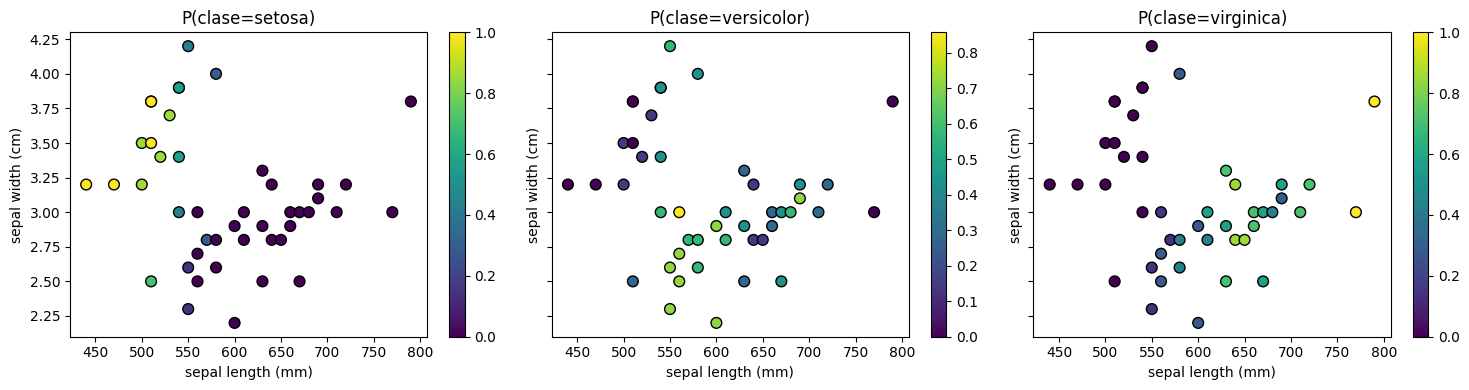

In [ ]:
proba = noscale_pipeline_fit.predict_proba(X_test)

n_classes = proba.shape[1]
fig, axes = plt.subplots(1, n_classes, figsize=(5 * n_classes, 4), sharex=True, sharey=True)

class_labels = getattr(dataset, 'target_names', None)
for class_idx, ax in enumerate(axes):
    label = class_labels[class_idx] if class_labels is not None else class_idx
    sc = ax.scatter(X_test[:, 0], X_test[:, 1], c=proba[:, class_idx],
                    cmap='viridis', s=60, edgecolors='k')
    ax.set_title(f'P(clase={label})')
    ax.set_xlabel(feature_names[0])
    ax.set_ylabel(feature_names[1])
    fig.colorbar(sc, ax=ax)

plt.tight_layout()


Trying with different number of neighbors:

k, train_error, test_error (muestra):
   1  0.0476  0.3111
  12  0.2095  0.2444
  24  0.1810  0.2444
  35  0.1905  0.2667
  47  0.2095  0.2889
  58  0.1905  0.2889
  70  0.2381  0.2889
  81  0.2476  0.2667
  93  0.3143  0.3111
 105  0.6476  0.7111


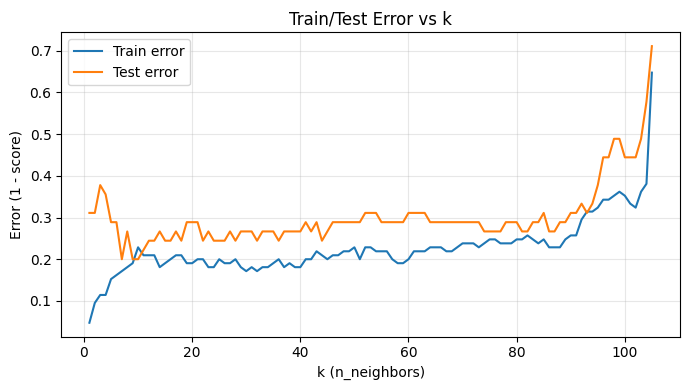

In [ ]:
n_train = X_train.shape[0]
k_values = list(range(1, n_train + 1))

train_errors = []
test_errors = []

for k in k_values:
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('kNN', neighbors.KNeighborsClassifier(n_neighbors=k, weights='uniform'))
    ])
    train_fit = pipe.fit(X_train, y_train)
    score_train = train_fit.score(X_train, y_train)
    score_test = train_fit.score(X_test, y_test)

    train_errors.append(1 - score_train)
    test_errors.append(1 - score_test)

# Muestra solo algunos valores numericos (10 equiespaciados)
print("k, train_error, test_error (muestra):")
for i in np.linspace(0, n_train - 1, 10, dtype=int):
    print(f"{k_values[i]:4d}  {train_errors[i]:.4f}  {test_errors[i]:.4f}")

plt.figure(figsize=(7, 4))
plt.plot(k_values, train_errors, label='Train error')
plt.plot(k_values, test_errors, label='Test error')
plt.xlabel('k (n_neighbors)')
plt.ylabel('Error (1 - score)')
plt.title('Train/Test Error vs k')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()  

Lower `k` $\rightarrow$ higher complexity of the model.